In [ ]:
import sys
import os

import matplotlib.pyplot as plt
import seaborn as sns
from copy import copy
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# sys.path.append(os.path.abspath('../../'))

from utils.feat_selection import *

In [2]:
from pathlib import Path
MAIN_DIR = Path().resolve().parent.parent
PATH_DATA = MAIN_DIR / 'data' / 'cleaned'
# where save the data after feature selection
PATH_FEAT_SELECT_DATA = MAIN_DIR / 'data' / 'feature_selection'

RANDOM_STATE = 42
THRESHOLD_CORR_FEATURES = 0.7
MAX_FEATURES = 80
CV_FOLDS = 3
MAX_ITER = 10000
rf = RandomForestRegressor(n_estimators=100, random_state=42)
MODEL = RandomForestRegressor(n_estimators=100, random_state=42)

In [3]:
train = pd.read_csv(PATH_DATA / 'train.csv')
val = pd.read_csv(PATH_DATA / 'valid.csv')
test  = pd.read_csv(PATH_DATA / 'test.csv')

In [4]:
DESCRIPTOR_NAMES = train.columns[4:-1]

# Feature Selection
Since we've an huge number of features, we need to select the most relevant ones for our task. This will help us reduce overfitting, improve model performance and decrease training time.

# Target split

In [5]:
X_train = train.drop(columns=["Y"])
y_train = train["Y"]
X_val = val.drop(columns=["Y"])
y_val = val["Y"]
X_test = test.drop(columns=["Y"])
y_test = test["Y"]

# Filter method (Spearman)

In [8]:
corr_with_target = (
    spearmanr(X_train[DESCRIPTOR_NAMES], y_train)[0][:-1, -1]
)
filter_ranking = pd.Series(
    np.abs(corr_with_target),
    index=DESCRIPTOR_NAMES,
).sort_values(ascending=False)

selected_filter = filter_ranking.index[:MAX_FEATURES].tolist()

print("Filter — selected features (in rank order):")
print(selected_filter)

c:\Users\giaco\anaconda3\envs\tox_prediction\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\giaco\anaconda3\envs\tox_prediction\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Filter — selected features (in rank order):
['mordred_MIC1', 'mordred_MIC2', 'mordred_ATS0m', 'mordred_ATS0Z', 'mordred_ATS2m', 'mordred_ATS1m', 'mordred_MIC3', 'mordred_MIC4', 'mordred_ATS2Z', 'mordred_MIC5', 'mordred_MID_h', 'mordred_SM1_Dzm', 'mordred_SM1_DzZ', 'mordred_ATS1Z', 'mordred_ATS3m', 'NumHeteroatoms', 'mordred_nHetero', 'mordred_AATS3m', 'mordred_Xpc-5dv', 'mordred_AATS3Z', 'mordred_Xpc-6dv', 'mordred_ATSC0Z', 'mordred_BCUTp-1h', 'mordred_ATSC0m', 'mordred_Xpc-4dv', 'mordred_AATS4p', 'mordred_ATS3Z', 'mordred_AATS1m', 'mordred_AATS1Z', 'mordred_Xp-3dv', 'Chi3v', 'mordred_ATS4m', 'mordred_AATS5p', 'mordred_AATS4Z', 'HeavyAtomMolWt', 'mordred_BCUTv-1h', 'mordred_AATS2Z', 'mordred_AATS3p', 'mordred_AATS4m', 'mordred_AATS2m', 'mordred_ATS4Z', 'mordred_IC0', 'mordred_MIC0', 'mordred_GATS1Z', 'MolWt', 'mordred_Sm', 'ExactMolWt', 'mordred_MW', 'mordred_Xp-4dv', 'mordred_Xp-2dv', 'mordred_GATS1m', 'Chi2v', 'Chi4v', 'mordred_AATS4v', 'mordred_AATS5Z', 'mordred_Xc-3dv', 'mordred_AT

# Random forest regressor feature importance

In [ ]:
rf.fit(X_train[DESCRIPTOR_NAMES], y_train)

importances = rf.feature_importances_

filter_ranking = pd.Series(
    np.abs(importances),
    index=DESCRIPTOR_NAMES,
).sort_values(ascending=False)

best_selected_rf = filter_ranking.index[:MAX_FEATURES].tolist()

print("Random forest regressor feature importance — selected features (in rank order):")
print(best_selected_rf)

Random forest regressor feature importance — selected features (in rank order):
['mordred_MIC1', 'mordred_MIC2', 'mordred_ATS0m', 'mordred_ATS0Z', 'mordred_ATS2m', 'mordred_ATS1m', 'mordred_MIC3', 'mordred_MIC4', 'mordred_ATS2Z', 'mordred_MIC5', 'mordred_MID_h', 'mordred_SM1_Dzm', 'mordred_SM1_DzZ', 'mordred_ATS1Z', 'mordred_ATS3m', 'NumHeteroatoms', 'mordred_nHetero', 'mordred_AATS3m', 'mordred_Xpc-5dv', 'mordred_AATS3Z', 'mordred_Xpc-6dv', 'mordred_ATSC0Z', 'mordred_BCUTp-1h', 'mordred_ATSC0m', 'mordred_Xpc-4dv', 'mordred_AATS4p', 'mordred_ATS3Z', 'mordred_AATS1m', 'mordred_AATS1Z', 'mordred_Xp-3dv', 'Chi3v', 'mordred_ATS4m', 'mordred_AATS5p', 'mordred_AATS4Z', 'HeavyAtomMolWt', 'mordred_BCUTv-1h', 'mordred_AATS2Z', 'mordred_AATS3p', 'mordred_AATS4m', 'mordred_AATS2m', 'mordred_ATS4Z', 'mordred_IC0', 'mordred_MIC0', 'mordred_GATS1Z', 'MolWt', 'mordred_Sm', 'ExactMolWt', 'mordred_MW', 'mordred_Xp-4dv', 'mordred_Xp-2dv', 'mordred_GATS1m', 'Chi2v', 'Chi4v', 'mordred_AATS4v', 'mordred_AA

# LASSO Feature importance

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[DESCRIPTOR_NAMES])

lasso = LassoCV(cv=CV_FOLDS, random_state=RANDOM_STATE, max_iter=MAX_ITER)
lasso.fit(X_train_scaled, y_train)

filter_ranking = pd.Series(
    np.abs(lasso.coef_),
    index=DESCRIPTOR_NAMES,
).sort_values(ascending=False)

best_selected_lasso = filter_ranking.index[:MAX_FEATURES].tolist()

print("Lasso feature importance — selected features (in rank order):")
print(best_selected_lasso)

c:\Users\giaco\anaconda3\envs\tox_prediction\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.418e-01, tolerance: 3.097e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\giaco\anaconda3\envs\tox_prediction\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.134e-01, tolerance: 3.097e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\giaco\anaconda3\envs\tox_prediction\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features o

Lasso feature importance — selected features (in rank order):
['mordred_MINdsssP', 'mordred_ATSC3d', 'mordred_nAcid', 'mordred_AMID_N', 'mordred_AATS8d', 'mordred_AMID_C', 'fr_ester', 'EState_VSA1', 'mordred_GATS6i', 'mordred_n9FRing', 'mordred_MAXdsssP', 'mordred_GATS1i', 'mordred_GATS1p', 'mordred_BCUTi-1h', 'mordred_VR3_A', 'mordred_BCUTv-1l', 'mordred_GATS3p', 'mordred_GATS5s', 'SlogP_VSA11', 'mordred_nG12FAHRing', 'mordred_MAXsssCH', 'mordred_ATSC3i', 'mordred_AATSC3i', 'mordred_ETA_dAlpha_B', 'mordred_MINssNH', 'fr_Al_OH_noTert', 'mordred_AATSC1v', 'SMR_VSA6', 'mordred_AXp-7dv', 'fr_oxazole', 'fr_oxime', 'mordred_MINsCH3', 'mordred_AATSC2p', 'mordred_n9FAHRing', 'NumSaturatedRings', 'fr_C_O_noCOO', 'fr_Al_COO', 'mordred_AATSC2dv', 'mordred_AATS8Z', 'mordred_n9FARing', 'mordred_ATSC6s', 'mordred_SaaN', 'mordred_ETA_dEpsilon_D', 'mordred_TIC1', 'mordred_MAXaaS', 'mordred_C3SP3', 'mordred_ATSC3se', 'mordred_ATSC5se', 'mordred_MAXddsN', 'mordred_MINsssCH', 'mordred_ATSC6i', 'mordred_

# Feature selection performances

In [11]:
model_filter = copy(MODEL)
model_filter.fit(X_train[selected_filter], y_train)
r2_filter = r2_score(y_test, model_filter.predict(X_test[selected_filter]))

model_fs = copy(MODEL)
model_fs.fit(X_train[best_selected_rf], y_train)
r2_fs = r2_score(y_test, model_fs.predict(X_test[best_selected_rf]))

model_cfs = copy(MODEL)
model_cfs.fit(X_train[best_selected_lasso], y_train)
r2_cfs = r2_score(y_test, model_cfs.predict(X_test[best_selected_lasso]))

print(f"R² (filter {len(selected_filter)} features) : {r2_filter:.3f}")
print(f"R² (RF {len(best_selected_rf)} features) : {r2_fs:.3f}")
print(f"R² (LASSO {len(best_selected_lasso)} features) : {r2_cfs:.3f}")

R² (filter 80 features) : 0.520
R² (RF 80 features) : 0.611
R² (LASSO 80 features) : 0.623


# Permutation feature importance (PFI)

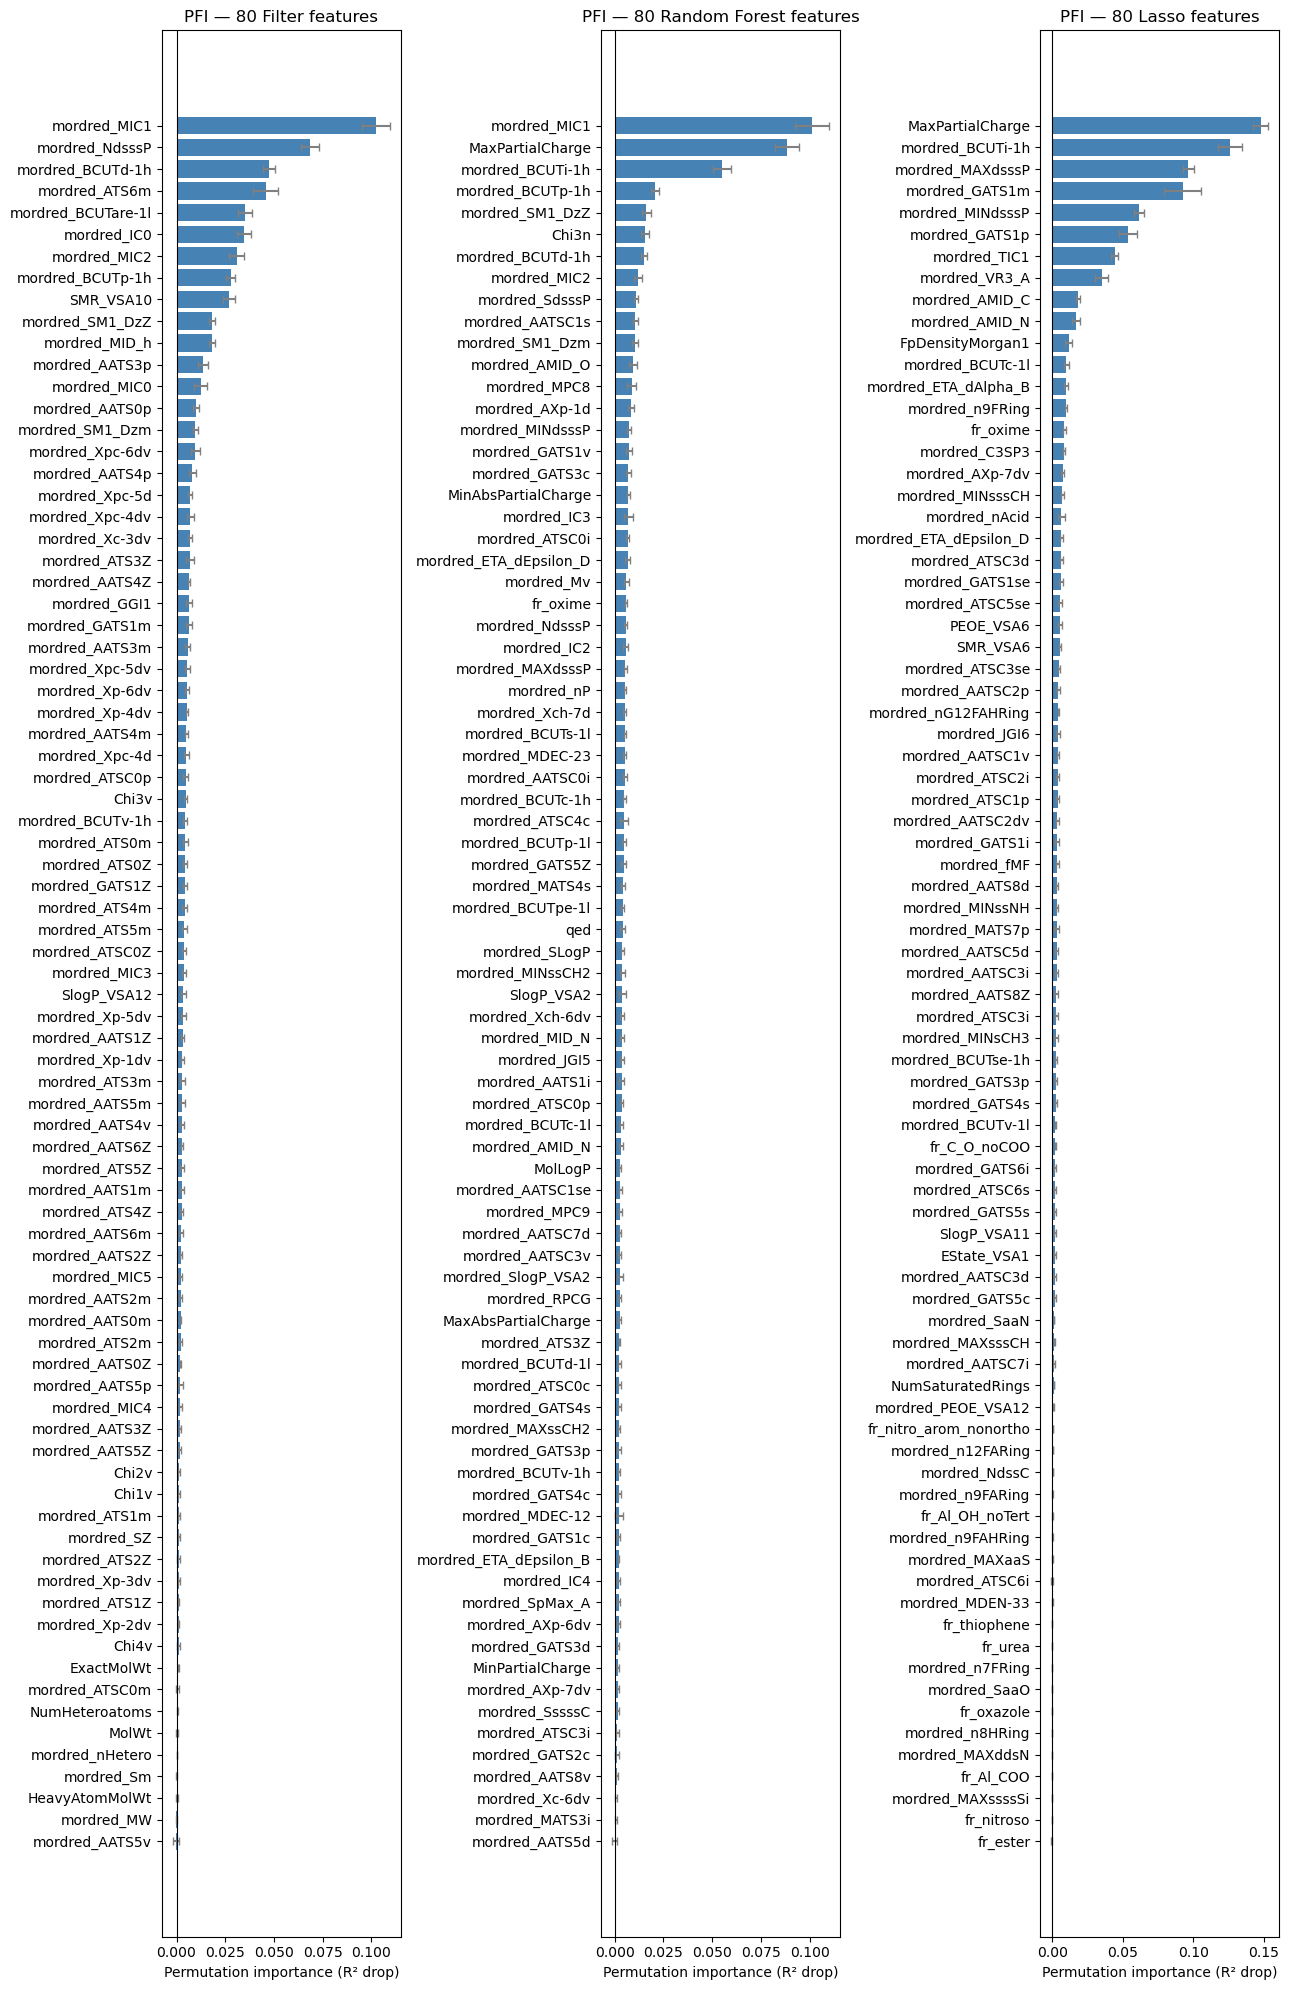

In [12]:
df_imp_filter = permutation_importance_df(
    model_filter, X_test[selected_filter], y_test, random_state=RANDOM_STATE
)
df_imp_fs = permutation_importance_df(
    model_fs, X_test[best_selected_rf], y_test, random_state=RANDOM_STATE
)
df_imp_cfs = permutation_importance_df(
    model_cfs, X_test[best_selected_lasso], y_test, random_state=RANDOM_STATE
)

# 3. Side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(13, 20))

for ax, df_imp, title in zip(
    axes,
    [df_imp_filter, df_imp_fs, df_imp_cfs],
    [f'PFI — {len(selected_filter)} Filter features',
     f'PFI — {len(best_selected_rf)} Random Forest features',
     f'PFI — {len(best_selected_lasso)} Lasso features'],
):
    ax.barh(
        df_imp['feature'],
        df_imp['importance_mean'],
        xerr=df_imp['importance_std'],
        align='center', color='steelblue', ecolor='gray', capsize=3,
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation importance (R² drop)')
    ax.set_title(title)
    ax.set_ylim(axes[0].get_ylim())

plt.tight_layout()
plt.show()

From the results showed by the PFI, for the spearman method, the importance is spread over too many similar feature, having in the end an R2 score of 0.52. The Lasso method,even if it show a slightly higher performance respect to the random forest method, it show a similar patter to the spearman method, with a really low R2 drop.
At last, the random forest method shows differentiate better importance of the features, showing some similar selection to the spearman method and a performance similar to the Lasso method (0.62).

As final decision we will use the first 20 features of the random forest method, because of the results achieved.

## Export Data

In [13]:
# Create output directory if needed
if not PATH_FEAT_SELECT_DATA.exists():
    PATH_FEAT_SELECT_DATA.mkdir(parents=True, exist_ok=True)

best_features = best_selected_rf[:20]

dfs = {'train': train[best_features], 'valid': val[best_features], 'test': test[best_features]}

for k, df in dfs.items():
    print(f"Exporting {k} set with shape {df.shape} to {PATH_FEAT_SELECT_DATA / f'{k}.csv'}")
    df.to_csv(PATH_FEAT_SELECT_DATA / f'{k}.csv', index=False)



Exporting train set with shape (5170, 20) to C:\Users\giaco\SUPSI\Anno_3\semestre_2\drug_design\progetto_drug_design\toxicity-prediction\data\feature_selection\train.csv
Exporting valid set with shape (738, 20) to C:\Users\giaco\SUPSI\Anno_3\semestre_2\drug_design\progetto_drug_design\toxicity-prediction\data\feature_selection\valid.csv
Exporting test set with shape (1477, 20) to C:\Users\giaco\SUPSI\Anno_3\semestre_2\drug_design\progetto_drug_design\toxicity-prediction\data\feature_selection\test.csv
